# PS-S06E01: XGBoost

This notebook tackles the [**Playground Series – Season 6, Episode 1: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s6e1), a competition focused on predicting the exam score for a student, based on features describing the student, the exam, and the facility.

## Introduction

**XGBoost** is highly effective at capturing non-linear relationships between physiological markers (like BMI and Blood Pressure) and the target. It handles missing values internally (if any exist) and includes regularization (L1/L2) to prevent overfitting on smaller datasets.
We will need to encode our categorical variables (One-Hot or Label Encoding) before feeding them into XGBoost, as it treats inputs as numerical matrices.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

In [1]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, roc_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e01_feature_engineering import FeatureFactory
from ps_s06e01_model_visualizer import ModelVisualizer
from ps_s06e01_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'exam_score'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

In [4]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba        6.850            65.200   
1  630001   18    male  diploma        6.610            45.000   
2  630002   24  female   b.tech        6.600            98.500   
3  630003   24    male  diploma        3.030            66.300   
4  630004   20  female   b.tech        2.030            42.400   

  internet_access  sleep_hours sleep_quality study_method facility_rating  \
0             yes        5.200          poor  group study            high   
1              no        9.300          poor     coaching             low   
2             yes        6.200          good  group study          medium   
3             yes        5.700       average        mixed          medium   
4             yes        9.200       average     coaching             low   

  exam_difficulty  
0            easy  
1            easy  
2        moderate  
3        moderate  
4        moderate  


## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'binning',
    'log',
    'polynomials',
    'interactions',
    'clustering',
    'manual_formula',
    'cyclical',
    'frequency'
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 12
New Feature Count: 49
   age  gender   course  study_hours  class_attendance internet_access  \
0   21  female     b.sc        7.910            98.800              no   
1   18   other  diploma        4.950            94.800             yes   
2   20  female     b.sc        4.680            92.600             yes   
3   19    male     b.sc        2.000            49.500             yes   
4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy 

## Optional Recursive Feature Elimination and Optuna Training

If the `PERFORM_RFE` variable in cell 3 is set to True, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.  This step is performed on a temporary feature engineered dataset to determine the optimal set of features, which are used to filter the in-fold feature engineered dataset.  If the variable is set to False, all features are used in training.

If the `PERFORM_OPTUNA_TUNING` variable in cell 3 is set to True, an Optuna trial is performed to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

In [7]:
n_jobs = 1 if USE_GPU else -1

# Convert object columns to 'category' dtype
X_rfe = X.copy()

# Identify string/object columns
cat_cols = X_rfe.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols:
    # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_rfe[cat_cols] = oe.fit_transform(X_rfe[cat_cols])
    
    # Ensure they are cast to integer type for XGBoost
    # We cast to 'category' type so XGBoost knows to treat them as discrete
    for col in cat_cols:
        X_rfe[col] = X_rfe[col].astype('category')
        
if PERFORM_RFE:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings('ignore', message='.*Falling back to prediction using DMatrix.*')
    
    # Use a "stfe" set of parameters
    rfe_params = {
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'max_depth': 6,          # Standard starting depth
        'colsample_bytree': 0.8, # Allow it to see most features
        'reg_alpha': 0.1,        # Light regularization only
        'device': 'cuda',
        'tree_method': 'hist',
        'enable_categorical': True
    }
    
    # 'gpu_hist' is removed. Now we use 'hist' + device='cuda'
    if USE_GPU:
        rfe_params['device'] = 'cuda'
    else:
        rfe_params['device'] = 'cpu'
    
    # Setup Model with Best Params
    # We use the exact same params that found the signal in the noise
    clf = xgb.XGBClassifier(**rfe_params)

    # Initialize RFECV
    # step=1: remove 1 feature at a time (most precise)
    # min_features_to_select=10: Don't go below 10 features
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=seed),
        scoring='roc_auc',
        min_features_to_select=15,
        n_jobs=n_jobs,
        verbose=0
    )
    
    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    rfecv.fit(X_rfe, y)
    
    # Results
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plot Performance vs Number of Features
    # Note: usage of cv_results_ depends on sklearn version, this is for recent versions
    n_scores = len(rfecv.cv_results_['mean_test_score'])
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross validation score (AUC)')
    plt.plot(
        range(10, 10 + n_scores),
        rfecv.cv_results_['mean_test_score']
    )
    plt.show()

    # Save the selected features for the next step
    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using all columns as optimal features.')
    optimal_cols = X_rfe.columns
    
print('\nOptimal Features:')
print(optimal_cols.tolist())

Using all columns as optimal features.

Optimal Features:
['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'log_age', 'log_study_hours', 'log_class_attendance', 'log_sleep_hours', 'age_sq', 'study_hours_sq', 'class_attendance_sq', 'sleep_hours_sq', 'high_study', 'study_to_sleep_ratio', 'attendance_to_study_ratio', 'total_engagement', 'autodidact_ratio', 'weighted_study_hours', 'restoration_index', 'study_att', 'effort_coaching_hours', 'effort_group_study_hours', 'effort_mixed_hours', 'effort_online_videos_hours', 'effort_self_study_hours', 'cluster_label', 'manual_formula', '_study_hours_sin', '_class_attendance_sin', 'gender_freq', 'course_freq', 'internet_access_freq', 'sleep_quality_freq', 'study_method_freq', 'facility_rating_freq', 'exam_difficulty_freq', 'class_attendance_class_freq', 'sleep_hour

In [8]:
# Filter the datasets to contain just the optimal features
X_rfe = X[optimal_cols]

def objective(trial):
    
    # Suggest Parameters
    param = {
        # Core Booster Params
        'n_estimators': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 50.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),  # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True), # L2
        'gamma': trial.suggest_float('gamma', 0.1, 5.0),
        
        # Tree Structure
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        
        # Boilerplate for Regression
        'objective': 'reg:squarederror',    # <--- Standard for RMSE
        'eval_metric': 'rmse',              # <--- Metric to optimize
        'tree_method': 'gpu_hist' if USE_GPU else 'hist',
        'enable_categorical': True,
        'early_stopping_rounds': 50,
        'random_state': seed,
        'n_jobs': n_jobs
    }

    # Ensure optimal_cols is a standard list for filtering
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
    # Initialize Standard K-Fold (Shuffle is critical for regression)
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    
    cv_scores = []

    # Standard CV Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_rfe, y)):
        
        # Create Folds
        X_train_fold = X_rfe.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        
        X_val_fold = X_rfe.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Restrict to optimal column set
        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError("No overlap between optimal_cols and fold feature columns.")
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]
        
        # Identify categorical columns for XGBoost
        # XGBoost requires 'category' dtype for enable_categorical=True
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
        if cat_cols:
            for c in cat_cols:
                X_train_trans[c] = X_train_trans[c].astype('category')
                X_val_trans[c]   = X_val_trans[c].astype('category')
            
        # Create model (Regressor)
        model = xgb.XGBRegressor(**param)

        # Train the model
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            verbose=False
        )
        
        # Predict
        val_preds = model.predict(X_val_trans)
        
        # CLIP predictions to valid range (0-100)
        # This is a critical optimization for RMSE on bounded targets
        val_preds = np.clip(val_preds, 0, 100)
        
        # Score this fold
        fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))
        cv_scores.append(fold_rmse)

    # Return the average RMSE across all folds
    return np.mean(cv_scores)


In [9]:
if PERFORM_OPTUNA_TUNING:
    print("Starting XGBoost Optuna Optimization...")
    
    # Use MedianPruner for efficiency
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10
    )
    
    study_xgb = optuna.create_study(
        direction='minimize',
        study_name='xgb_student_test_scores_optuna', 
        pruner=pruner
    )
    
    study_xgb.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )
    
    print("\nBest Trial:")
    print(f"  RMSE: {study_xgb.best_value:.5f}")
    print("  Params: ", study_xgb.best_params)
    
    xgb_best_params = study_xgb.best_params
else:
    xgb_best_params = {
        'learning_rate': 0.03427440488577553,
        'max_depth': 6,
        'min_child_weight': 6.862433902739885,
        'subsample': 0.9057463612437909,
        'colsample_bytree': 0.6676990920389291,
        'reg_alpha': 8.026948631559733,
        'reg_lambda': 1.8707451418446663,
        'gamma': 0.766714307564982,
        'grow_policy': 'depthwise'
    }
    
    print("\nUsing earlier calculated params:")
    print("  Params: ", xgb_best_params)


[I 2026-01-16 16:56:01,096] A new study created in memory with name: xgb_student_test_scores_optuna


Starting XGBoost Optuna Optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-01-16 17:01:48,052] Trial 0 finished with value: 8.719865701338735 and parameters: {'learning_rate': 0.021711505357299495, 'max_depth': 8, 'min_child_weight': 2.016247944000096, 'subsample': 0.5270534246567364, 'colsample_bytree': 0.5423189589726762, 'reg_alpha': 0.03888885453399062, 'reg_lambda': 3.5350629993079936, 'gamma': 3.3340303106475524, 'grow_policy': 'depthwise'}. Best is trial 0 with value: 8.719865701338735.
[I 2026-01-16 17:26:33,740] Trial 1 finished with value: 8.713303089505741 and parameters: {'learning_rate': 0.0120127909856432, 'max_depth': 8, 'min_child_weight': 3.989617456381555, 'subsample': 0.5792122144920544, 'colsample_bytree': 0.5187866595708934, 'reg_alpha': 0.03216209277553503, 'reg_lambda': 0.06128175924685183, 'gamma': 2.732106789941505, 'grow_policy': 'lossguide'}. Best is trial 1 with value: 8.713303089505741.
[I 2026-01-16 17:44:56,694] Trial 2 finished with value: 8.705339592730281 and parameters: {'learning_rate': 0.01663197955420485, 'max_dep

## Model Training

In [10]:
xgb_tuned_params = {
    **xgb_best_params, # Unpack Optuna best params
    'n_estimators': 5000,
    'objective': 'reg:squarederror', # Standard for Regression
    'eval_metric': 'rmse',           # Metric to optimize
    'n_jobs': n_jobs,
    'random_state': seed,
    'early_stopping_rounds': 100,
    'tree_method': 'gpu_hist' if USE_GPU else 'hist',
    'enable_categorical': True,
}

print('Final XGBoost CV Training with OOF / Test predictions')
print('======================================================')
print('Parameters used for training:')
print(xgb_tuned_params)

# Ensure optimal_cols is a standard list
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Initialize Standard K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_preds = np.zeros(len(y))
test_preds = np.zeros(len(test_df))

# Standard CV Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X_rfe, y)):

    print(f"Starting processing of fold {fold+1}")

    # Create Folds
    X_train_fold = X_rfe.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    X_val_fold = X_rfe.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Feature Engineering
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)
    
    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError("No overlap between optimal_cols and fold feature columns.")
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    # Handle Categoricals
    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()

    if cat_cols:
        # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_train_trans[cat_cols] = oe.fit_transform(X_train_trans[cat_cols])
        X_val_trans[cat_cols] = oe.transform(X_val_trans[cat_cols])
        X_test_trans[cat_cols] = oe.transform(X_test_trans[cat_cols])

        # Cast to 'category' so XGBoost handles them as discrete partitions
        for col in cat_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col] = X_val_trans[col].astype('category')
            X_test_trans[col] = X_test_trans[col].astype('category')
        
    # Create model (Regressor)
    model = xgb.XGBRegressor(**xgb_tuned_params)
    
    # Train Model
    model.fit(
        X_train_trans, y_train_fold,
        # eval_set order: [validation, train] so we can track both
        eval_set=[(X_val_trans, y_val_fold), (X_train_trans, y_train_fold)],
        verbose=500
    )
    
    # Store history
    eval_results.append(model.evals_result())
    models.append(model)
    
    # Predict OOF (Regression returns values directly)
    val_preds = model.predict(X_val_trans)
    
    # CLIP predictions (Critical for RMSE optimization)
    val_preds = np.clip(val_preds, 0, 100)
    
    oof_preds[val_idx] = val_preds
    
    # Score this fold
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))
    print(f"Fold {fold+1} RMSE: {fold_rmse:.5f} (best_iteration={model.best_iteration})")
    
    # Accumulate Test Preds
    batch_test_preds = model.predict(X_test_trans)
    batch_test_preds = np.clip(batch_test_preds, 0, 100)
    test_preds += batch_test_preds / n_folds

# Final Metric Calculation
overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nOverall CV RMSE: {overall_rmse:.5f}")

Final XGBoost CV Training with OOF / Test predictions
Parameters used for training:
{'learning_rate': 0.03427440488577553, 'max_depth': 6, 'min_child_weight': 6.862433902739885, 'subsample': 0.9057463612437909, 'colsample_bytree': 0.6676990920389291, 'reg_alpha': 8.026948631559733, 'reg_lambda': 1.8707451418446663, 'gamma': 0.766714307564982, 'grow_policy': 'depthwise', 'n_estimators': 5000, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'n_jobs': 1, 'random_state': 10301, 'early_stopping_rounds': 100, 'tree_method': 'gpu_hist', 'enable_categorical': True}
Starting processing of fold 1
[0]	validation_0-rmse:18.46289	validation_1-rmse:18.44493
[500]	validation_0-rmse:8.76131	validation_1-rmse:8.65816
[1000]	validation_0-rmse:8.73032	validation_1-rmse:8.54693
[1500]	validation_0-rmse:8.71594	validation_1-rmse:8.45626
[2000]	validation_0-rmse:8.70712	validation_1-rmse:8.37536
[2500]	validation_0-rmse:8.70239	validation_1-rmse:8.30029
[3000]	validation_0-rmse:8.70002	validation_1-

## Visualizing Model Performance
We use four key plots to diagnose the health of our regression model

### Learning Curves (Train vs. Validation RMSE)
This plot tracks the Root Mean Squared Error (RMSE) for both the training set (Blue) and validation set (Red) over each boosting iteration.

* **What to look for:** You want the Validation (Red) curve to go down and flatten out.
* **Overfitting:** If the Blue line keeps dropping rapidly but the Red line starts rising, the model is memorizing the training data.
* **Underfitting:** If both lines are high and flat, the model isn't learning enough complexity.
* **Ideal:** The Red line reaches a minimum low value and stays there. The gap between Blue and Red should not be massive.

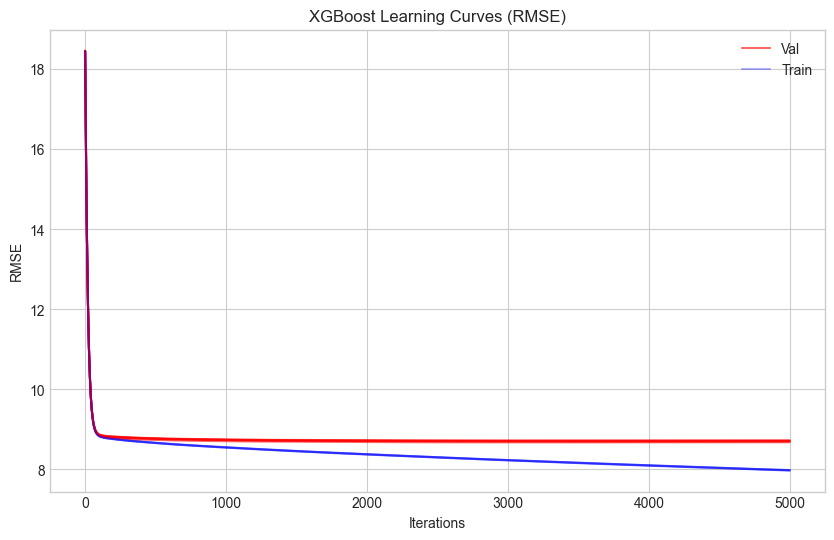

In [11]:
mviz = ModelVisualizer(model_name='XGBoost')

mviz.plot_learning_curves(eval_results)

### Feature Importance
This bar chart ranks which columns had the biggest impact on the model's predictions.
* **Validation Check:** Ensure the top features make sense (e.g., `study_hours` or `class_attendance` should likely be high).
* **Sanity Check:** If `id` or a random noise column appears in the top 5, there is a data leakage problem.
* **Engineering Check:** Look for the engineered features (e.g., `restoration_index`, `interaction_score`). If they appear near the top, the feature engineering added real value.

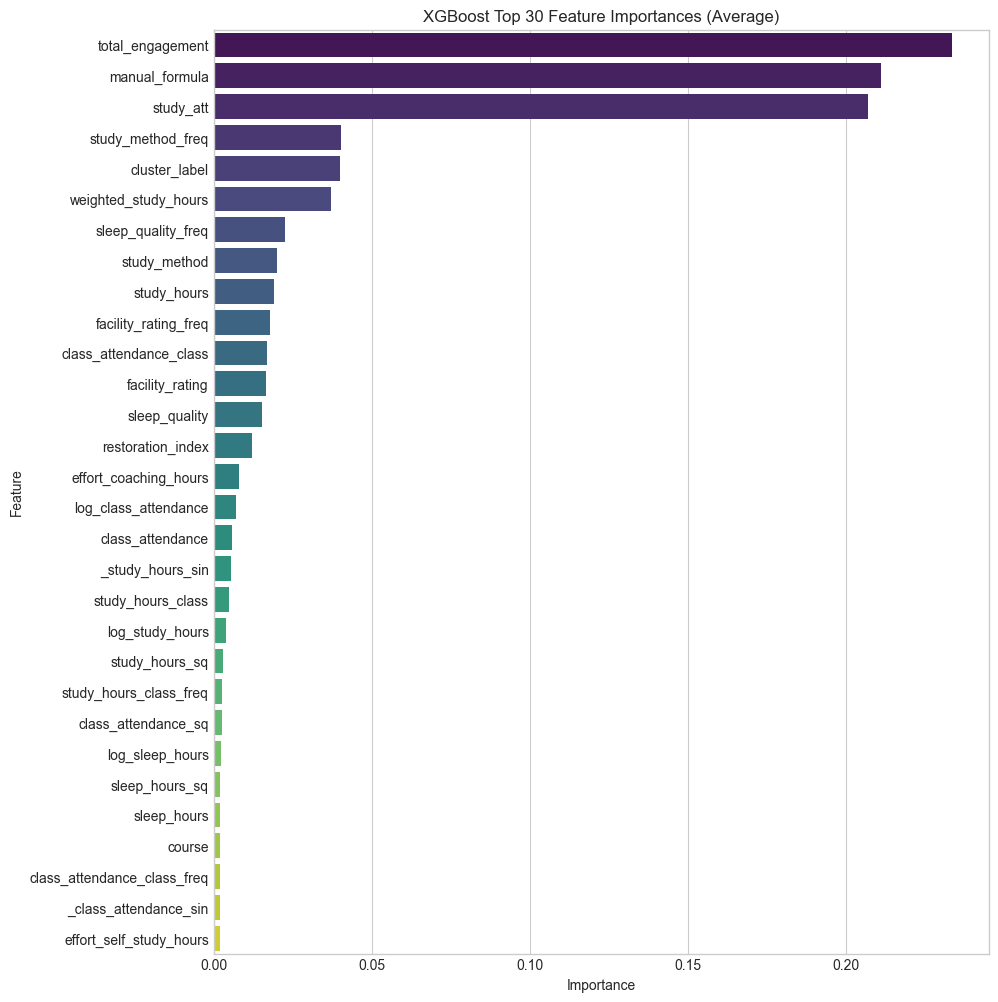

In [12]:
mviz.plot_feature_importance(models, show_values=True)

### Prediction Error Plot (True vs. Predicted)
This scatter plot compares the **Actual Exam Scores** (X-axis) against what the model **Predicted** (Y-axis).
* **The Red Line:** This represents "Perfect Prediction."
* **Tight Cloud:** The closer the blue dots are to the red dashed line, the better the model.
* **Bias Detection:**
    * If dots at the bottom left (low scores) are consistently above the line, the model is over-predicting struggling students.
    * If dots at the top right (high scores) are below the line, the model is under-predicting top performers.

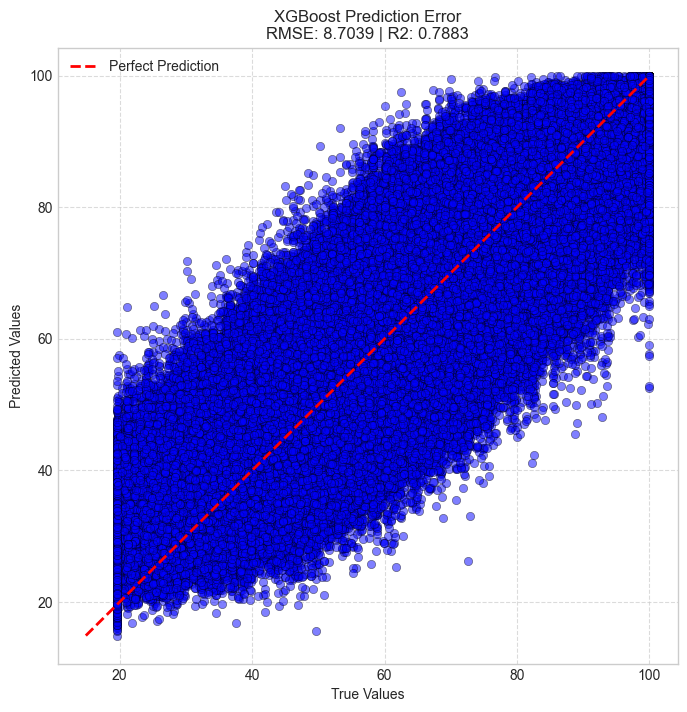

In [13]:
mviz.plot_prediction_error(y, oof_preds)

### Residual Plot
This plot shows the **Error** (True - Predicted) on the Y-axis against the **Predicted Score** on the X-axis.
* **The Goal:** You want a random cloud of points centered around the red line (0 error).
* **Bad Patterns:**
    * **Funnel Shape:** If the cloud gets wider as the score increases, the model is less certain about high-scoring students.
    * **U-Shape: If the points dip in the middle, the model is missing a non-linear relationship (e.g., it's fitting a straight line to a curved trend).
* **Outliers:** Dots that are very far from the center line represent students the model completely misjudged. Investigating these specific rows often reveals data quality issues.

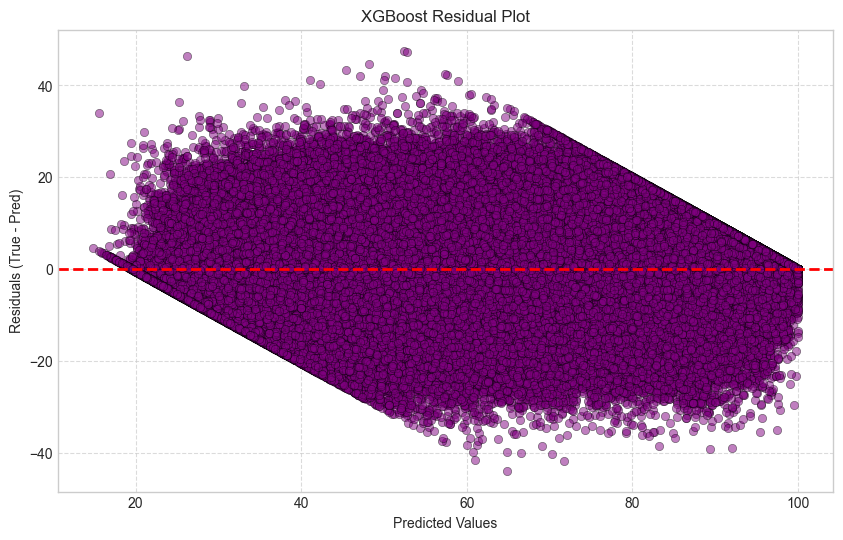

In [14]:
mviz.plot_residuals(y, oof_preds)

## Prepare Submission

In [15]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  exam_score
0  630000      71.109
1  630001      71.765
2  630002      88.064
3  630003      55.973
4  630004      47.648
5  630005      70.131
6  630006      72.845
7  630007      58.089
8  630008      78.663
9  630009      90.440


In [16]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [17]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_xgb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/xgb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_xgb': test_preds})
test_pred_df.to_csv(f'{output_dir}/xgb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/xgb_oof_preds.csv, {output_dir}/xgb_test_preds.csv')

Saved for Blending: predictions/xgb_oof_preds.csv, predictions/xgb_test_preds.csv
